In [1]:
import pandas as pd
import torch
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("01-study_hours_grades.csv")
df.head()

,study_hours,grade
0,3.745401,30.203939
1,9.507143,57.878452
2,7.319939,46.368401
3,5.986585,39.330717
4,1.560186,14.843888


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   study_hours  50 non-null     float64
 1   grade        50 non-null     float64
dtypes: float64(2)
memory usage: 932.0 bytes


In [4]:
X = torch.tensor(df['study_hours'].values,dtype=torch.float32).unsqueeze(1)
y = torch.tensor(df['grade'].values,dtype=torch.float32).unsqueeze(1)

In [5]:
X.shape

torch.Size([50, 1])

In [6]:
X.ndim

2

In [7]:
X

tensor([[3.7454],
        [9.5071],
        [7.3199],
        [5.9866],
        [1.5602],
        [1.5599],
        [0.5808],
        [8.6618],
        [6.0111],
        [7.0807],
        [0.2058],
        [9.6991],
        [8.3244],
        [2.1234],
        [1.8182],
        [1.8340],
        [3.0424],
        [5.2476],
        [4.3195],
        [2.9123],
        [6.1185],
        [1.3949],
        [2.9214],
        [3.6636],
        [4.5607],
        [7.8518],
        [1.9967],
        [5.1423],
        [5.9241],
        [0.4645],
        [6.0754],
        [1.7052],
        [0.6505],
        [9.4889],
        [9.6563],
        [8.0840],
        [3.0461],
        [0.9767],
        [6.8423],
        [4.4015],
        [1.2204],
        [4.9518],
        [0.3439],
        [9.0932],
        [2.5878],
        [6.6252],
        [3.1171],
        [5.2007],
        [5.4671],
        [1.8485]])

In [8]:
# train - test olarak datalarımızı böldük
train_split = int(0.8 * len(X))
X_train , y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [9]:
len(X_train), len(X_test)

(40, 10)

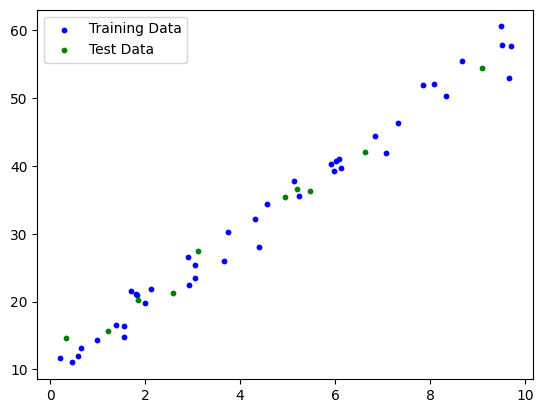

In [10]:
plt.scatter(X_train,y_train,c="b",s=10,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=10, label= "Test Data")
plt.legend()
plt.show()

In [11]:
import torch.nn as nn 

class LinearRegressionModel(nn.Module):
    
    def __init__(self):
        super().__init__()

        # burada manuel tanımlama yerine bu işlemleri yapıyoruz.
        # in_features = 1 olmasının sebebi bizim 1 girdimiz olacak çıktımız da en son katmanda 1 olacak
        # Çünkü study hours'ları alıyoruz ve grades leri veriyoruz.
        self.linear_layer = nn.Linear(in_features=1,out_features=1)
        # self.linear_layer2 = nn.Linear(in_features=1, out_features=1)
        # katman sayısını artırmak istersek burayı ona göre ayarlayabiliriz.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)
        # return self.linear_layer3(self.linear_layer2(self.linear_layer(x)))
        # Eğer cok katmanlı olsaydı 1 üstteki satır gibi yapacaktık.

In [12]:
torch.manual_seed(42)
model = LinearRegressionModel()

In [13]:
model

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [14]:
model.state_dict()
# weight'lerimizi random olarak oluşturdu layerlarımız.

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [15]:
loss_fn = nn.MSELoss() # Yine MSE loss function'u seçtik

optimizer = torch.optim.SGD(params=model.parameters(),lr=0.001) # Aynı şekilde optimizer'ıda aynı seçtik

In [16]:
epochs = 120

for epoch in range(epochs):
    model.train()
    # X_train datamız Double kullanıyor float64 fakat layerlarımız float32 kullanıyor
    # same size'da olmadıkları için hata aldık feed-forward aşamasında
    # bunun için en başta datayı alırkenki kodlarımızı dtype=torch.float32 şeklinde güncelledik.
    # Bu hatayı düzeltince de shape hatası aldık linearlayer kısmında
    # Çünkü in_features= 1 'di fakat biz 40 features vermeye çalışıyoruz.
    # Aslında biz 40 satır yolluyoruz fakat 40 sütun gibi yolladığımızı algılamış.
    # Tek boyutlu olduğu için biz torch.Size([40]) olarak yolluyoruz
    # X_train'i unsqueeze edersek torch.Size([40, 1]) olacağı için problememiz çözüldü
    y_pred = model(X_train)

    loss = loss_fn(y_pred,y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model.eval()
    with torch.inference_mode():
        test_pred = model(X_test)
        test_loss = loss_fn(test_pred,y_test)

        if epoch % 5 == 0:
            print(f"Epoch: {epoch}, Train loss: {loss}, Test loss {test_loss}")

Epoch: 0, Train loss: 965.6339721679688, Test loss 717.683349609375
Epoch: 5, Train loss: 530.086669921875, Test loss 405.685546875
Epoch: 10, Train loss: 295.7361755371094, Test loss 236.03225708007812
Epoch: 15, Train loss: 169.6184539794922, Test loss 143.42544555664062
Epoch: 20, Train loss: 101.72415924072266, Test loss 92.61089324951172
Epoch: 25, Train loss: 65.15110778808594, Test loss 64.53108215332031
Epoch: 30, Train loss: 45.427330017089844, Test loss 48.86598587036133
Epoch: 35, Train loss: 34.767799377441406, Test loss 40.014488220214844
Epoch: 40, Train loss: 28.984630584716797, Test loss 34.92718505859375
Epoch: 45, Train loss: 25.824926376342773, Test loss 31.93711280822754
Epoch: 50, Train loss: 24.0767879486084, Test loss 30.128173828125
Epoch: 55, Train loss: 23.088253021240234, Test loss 28.993366241455078
Epoch: 60, Train loss: 22.508625030517578, Test loss 28.2496337890625
Epoch: 65, Train loss: 22.14923667907715, Test loss 27.737096786499023
Epoch: 70, Train los

In [18]:
print(model.state_dict())
# Manuel yaptığımızda 6.29 ve 1.66 civarında bulmuştuk

OrderedDict([('linear_layer.weight', tensor([[6.2079]])), ('linear_layer.bias', tensor([2.2388]))])


In [19]:
model.eval()
with torch.inference_mode():
    y_preds = model(X_test)

In [20]:
y_preds

tensor([[ 9.8148],
        [32.9787],
        [ 4.3736],
        [58.6882],
        [18.3035],
        [43.3673],
        [21.5894],
        [34.5239],
        [36.1778],
        [13.7143]])

In [21]:
y_test

tensor([[15.6626],
        [35.4731],
        [14.6752],
        [54.4295],
        [21.3220],
        [42.1226],
        [27.4164],
        [36.6609],
        [36.2760],
        [20.2693]])

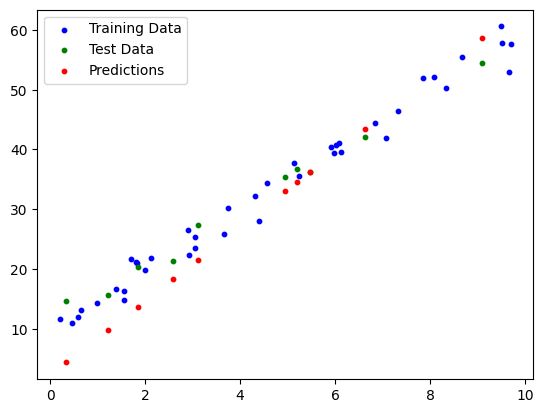

In [22]:
plt.scatter(X_train,y_train,c="b",s=10,label="Training Data")
plt.scatter(X_test,y_test,c="g",s=10,label="Test Data")
plt.scatter(X_test,y_preds,c="r",s=10, label="Predictions")
plt.legend()
plt.show()